# Pipeline 3 - Create the reference mask

## Imports


In [1]:
%load_ext autoreload
%autoreload 2

from pathlib import Path

from swot_toolkit.pipe2 import open_output_dir
from swot_toolkit.pipe3 import create_random_samples, open_s2_img

OUTPUT_DIR = "/data/swot/output/Curua-Una"
DATE = "2025-08-14"  # Date of the mosaic

output_dir, aoi, s2_id = open_output_dir(OUTPUT_DIR, DATE)


Reading KML file: /data/swot/output/Curua-Una/kml/Curua-Una.kml


## Open the Reference Image

In [2]:
s2_img, scl = open_s2_img(s2_id, output_dir)

## Create Random Samples

Create a first set of control  points and save it to `"training_samples"` folder.

/workspaces/swot/.venv/lib/python3.12/site-packages/pyogrio/geopandas.py:710: UserWarning: 'crs' was not provided.  The output dataset will not have projection information defined and may not be usable in other systems.
  write(


<Axes: >

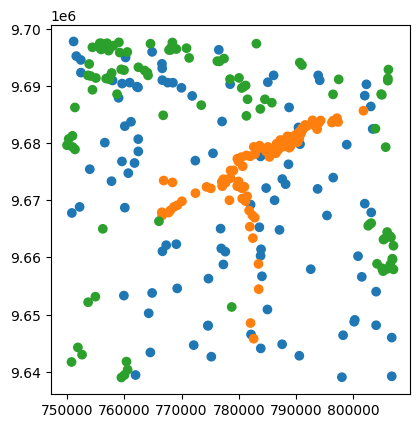

In [3]:
scl_samples_df = create_random_samples(scl, output_dir=output_dir)
scl_samples_df.plot(column="class", cmap="tab10", vmin=0, vmax=10)

## Create the reference mask

In [5]:
import matplotlib.pyplot as plt

from swot_toolkit.pipe3 import create_ref_mask

In [13]:
ref_mask = create_ref_mask(s2_img, output_dir, _id=s2_id)

Using 338 training samples.
Training the RF classifier...
Predicting the full image...


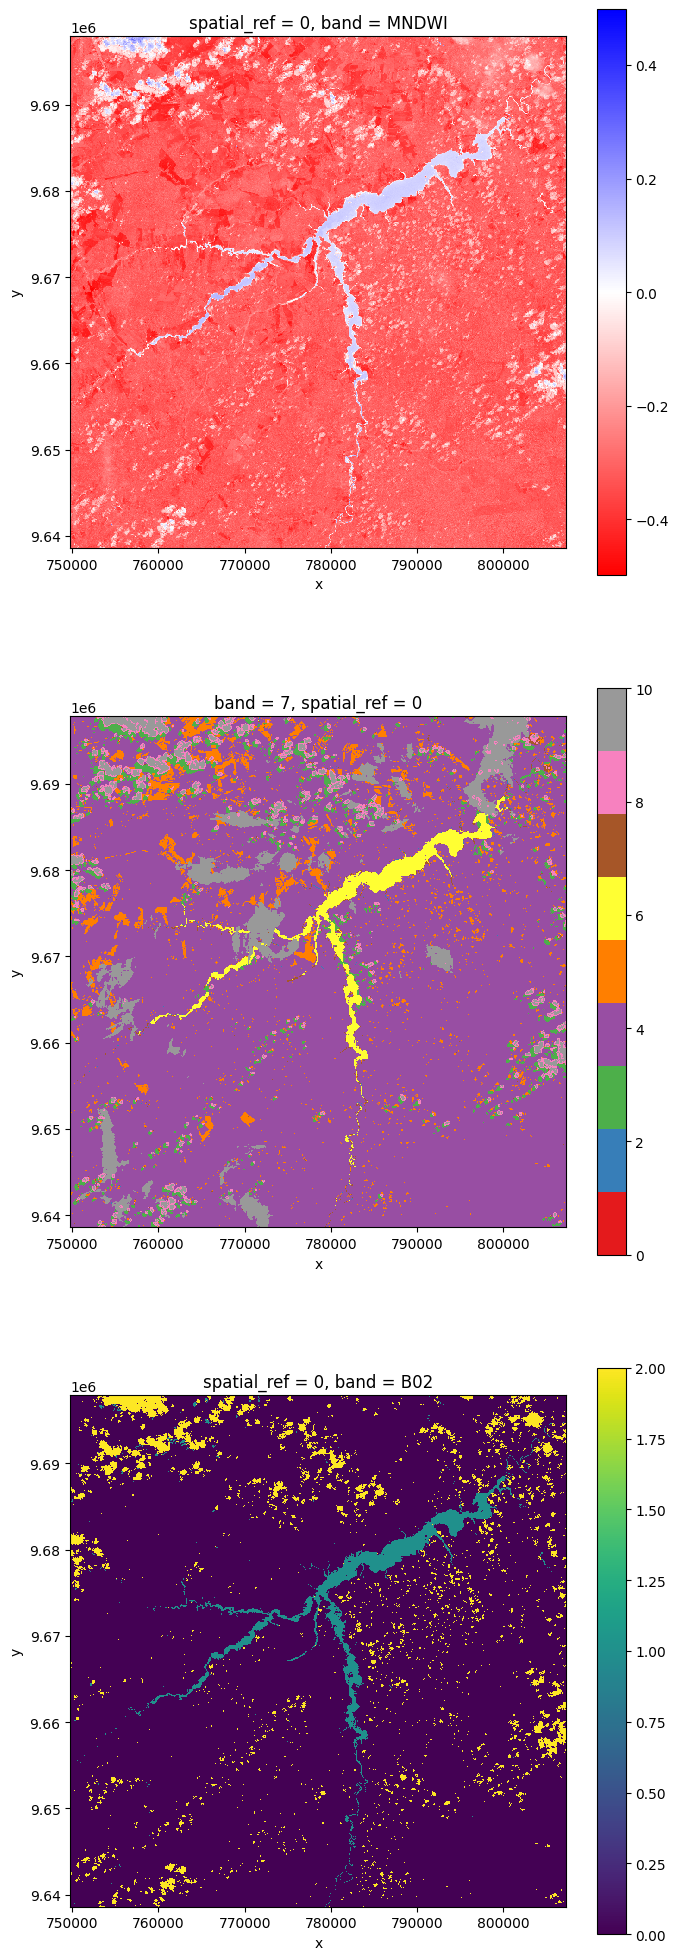

In [14]:
fig, axs = plt.subplots(3, 1, figsize=(8, 25))
s2_img.sel(x=slice(None, None, 10), y=slice(None, None, 10), band="MNDWI").plot.imshow(
    cmap="bwr_r", ax=axs[0]
)
scl.sel(x=slice(None, None, 10), y=slice(None, None, 10)).plot.imshow(
    cmap="Set1", vmin=0, vmax=10, ax=axs[1]
)
ref_mask.sel(x=slice(None, None, 10), y=slice(None, None, 10)).plot.imshow(ax=axs[2])

for ax in axs:
    ax.set_aspect("equal")

## Post-processing

In [ ]:
# import rioxarray as xrio
# full_pred = xrio.open_rasterio(output_dir / "ref_masks" / f"ref_mask_{s2_ids[DATE]}.tif").squeeze()

In [16]:
from swot_toolkit.pipe3 import post_process_ref_mask

final_mask = post_process_ref_mask(ref_mask, shadow_displacement=(-30, 27))

final_mask.rio.to_raster(
    output_dir / "ref_mask" / f"ref_mask_{s2_id}_processed.tif",
    compress="DEFLATE",
)